In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
from xgboost import plot_importance
import shap

In [10]:
import pandas as pd

data = pd.read_csv("../data/final_dataset.csv")

train = data[data["year"] <= 2015]
val   = data[(data["year"] >= 2016) & (data["year"] <= 2017)]
test  = data[data["year"] >= 2018]

X_train = train.drop(columns=["y","year"])
y_train = train["y"]

X_val = val.drop(columns=["y","year"])
y_val = val["y"]

X_test = test.drop(columns=["y","year"])
y_test = test["y"]

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [12]:
import joblib

log_reg = joblib.load("../models/log_reg.pkl")
rf = joblib.load("../models/rf.pkl")
xgb = joblib.load("../models/xgb.pkl")

print("Models loaded.")

Models loaded.


In [13]:
models = {
    "LogReg": log_reg,
    "RandomForest": rf,
    "XGBoost": xgb
}

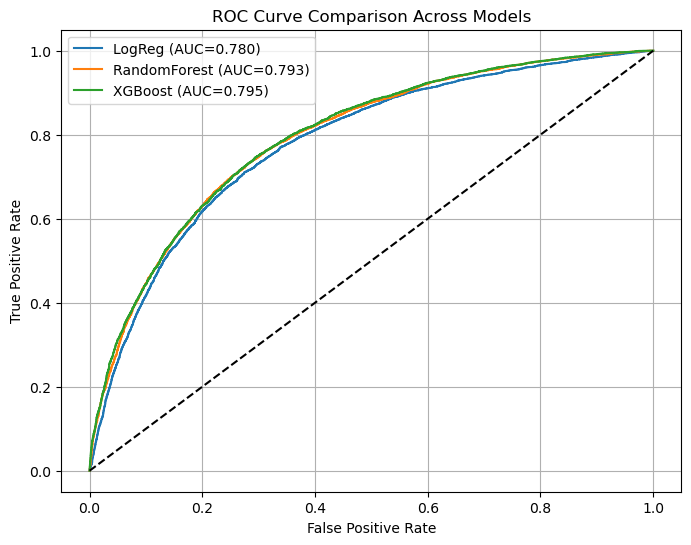

In [14]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for name, model in models.items():
    if name == "LogReg":
        proba = model.predict_proba(X_test_s)[:,1]
    else:
        proba = model.predict_proba(X_test)[:,1]
    
    auc = roc_auc_score(y_test, proba)
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1], [0,1], 'k--')
plt.title("ROC Curve Comparison Across Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

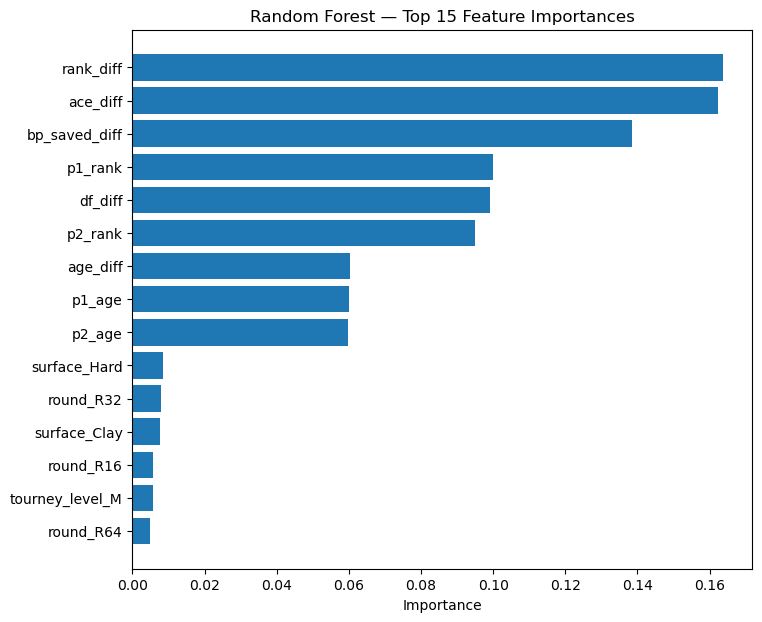

In [15]:
# RANDOM FOREST FEATURE IMPORTANCES
import numpy as np
import matplotlib.pyplot as plt

importances = rf.feature_importances_
idx = np.argsort(importances)[-15:]  # top 15

plt.figure(figsize=(8,7))
plt.barh(range(len(idx)), importances[idx])
plt.yticks(range(len(idx)), X_train.columns[idx])
plt.xlabel("Importance")
plt.title("Random Forest — Top 15 Feature Importances")
plt.show()

<Figure size 800x700 with 0 Axes>

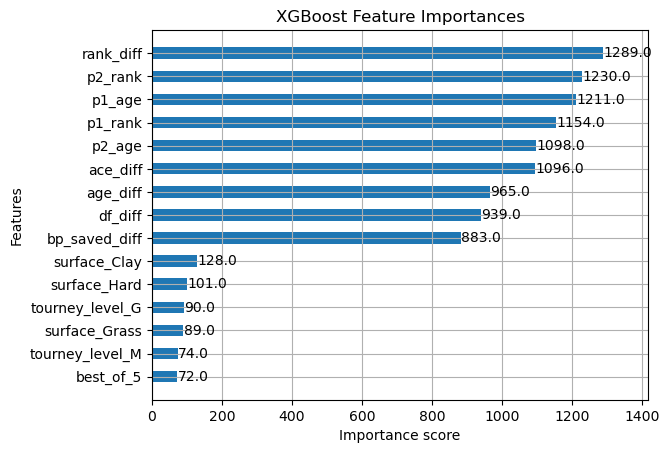

In [16]:
# XGBOOST FEATURE IMPORTANCES
from xgboost import plot_importance

plt.figure(figsize=(8,7))
plot_importance(xgb, max_num_features=15, height=0.5)
plt.title("XGBoost Feature Importances")
plt.show()

In [29]:
X_test.head()
X_test.dtypes

rank_diff          float64
age_diff           float64
ace_diff           float64
df_diff            float64
bp_saved_diff      float64
p1_rank            float64
p2_rank            float64
p1_age             float64
p2_age             float64
surface_Clay          bool
surface_Grass         bool
surface_Hard          bool
tourney_level_D       bool
tourney_level_F       bool
tourney_level_G       bool
tourney_level_M       bool
round_ER              bool
round_F               bool
round_QF              bool
round_R128            bool
round_R16             bool
round_R32             bool
round_R64             bool
round_RR              bool
round_SF              bool
best_of_5             bool
dtype: object

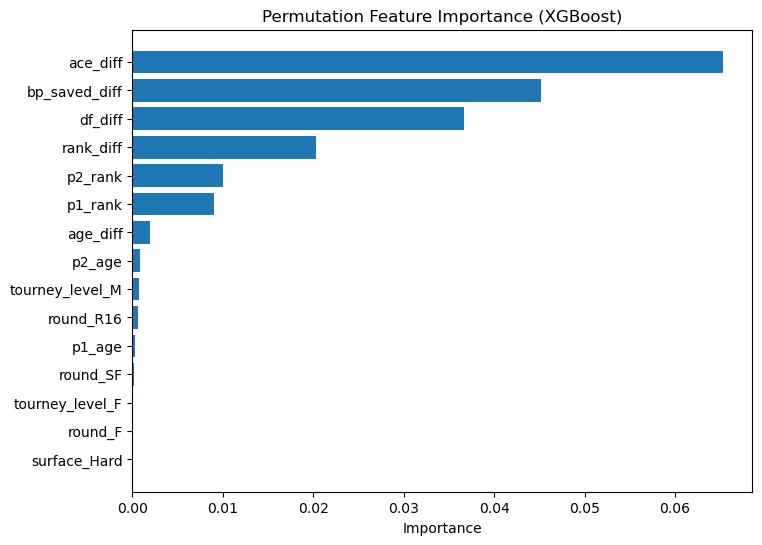

In [30]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    xgb,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importances = result.importances_mean
indices = np.argsort(importances)[-15:]  # top 15 features

plt.figure(figsize=(8,6))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), X_test.columns[indices])
plt.title("Permutation Feature Importance (XGBoost)")
plt.xlabel("Importance")
plt.show()

“To evaluate feature importance in a model-agnostic way, we used Permutation Feature Importance (PFI).
PFI measures how much the model’s performance drops when a feature is shuffled, reflecting the true dependency of the model on that feature.
Ranking differentials and serve performance statistics remain the most influential predictors of ATP match outcomes.”

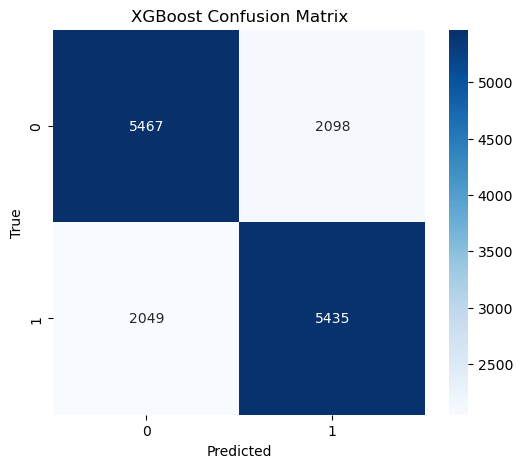

In [31]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion(model, X, y, title):
    y_pred = model.predict(X)
    cm = confusion_matrix(y, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

plot_confusion(xgb, X_test, y_test, "XGBoost Confusion Matrix")

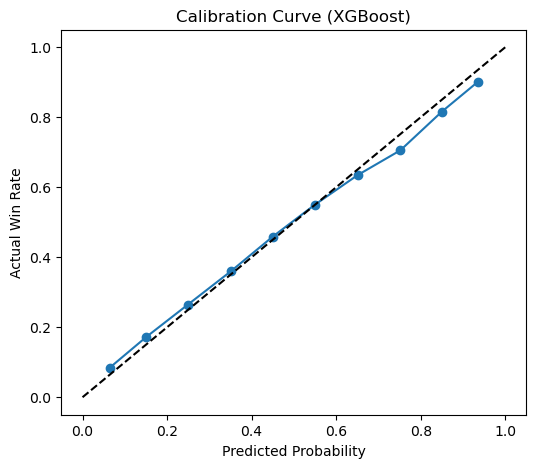

In [32]:
from sklearn.calibration import calibration_curve

proba = xgb.predict_proba(X_test)[:,1]
true_prob, pred_prob = calibration_curve(y_test, proba, n_bins=10)

plt.figure(figsize=(6,5))
plt.plot(pred_prob, true_prob, marker='o')
plt.plot([0,1],[0,1],'k--')
plt.title("Calibration Curve (XGBoost)")
plt.xlabel("Predicted Probability")
plt.ylabel("Actual Win Rate")
plt.show()

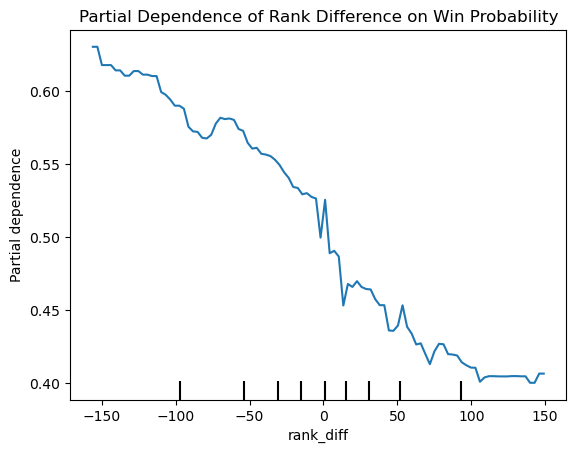

In [33]:
from sklearn.inspection import PartialDependenceDisplay

PartialDependenceDisplay.from_estimator(
    xgb,
    X_test,
    features=["rank_diff"],
    kind="average"
)
plt.title("Partial Dependence of Rank Difference on Win Probability")
plt.show()